___
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://static.nationalgeographicla.com/files/styles/image_3200/public/ovosfotopaulolanzettaembrapa.jpeg.webp?w=1600&h=1068" width="380px" height="200px" />


# <font color= #bbc28d> **Modelo ARIMA - Precio promedio de la docena de huevo** </font>
#### <font color= #2E9AFE> `Tarea 2 - MNLP`</font>
- <Strong> Diana Valdivia, Samantha Sanchez, Clara Aguilar & Daniela de la Torre. </Strong>
- <Strong> Fecha </Strong>: 15/02/2026.

___

<p style="text-align:right;"> Image retrieved from: https://static.nationalgeographicla.com/files/styles/image_3200/public/ovosfotopaulolanzettaembrapa.jpeg.webp?w=1600&h=1068</p>

# <font color=#bbc28d> **Datos Iniciales** </font>
El dataset **“Average Price: Eggs, Grade A, Large (Cost per Dozen) in U.S. City Average (APU0000708111)”** contiene información histórica sobre el **precio promedio al consumidor de huevos grado A, tamaño grande**, medido como **costo por docena** en el **promedio de ciudades de Estados Unidos**.

Los datos son recolectados y publicados por el **U.S. Bureau of Labor Statistics (BLS)** como parte del **Consumer Price Index (CPI)**, y reflejan la evolución de los precios que enfrentan los consumidores en el mercado minorista a lo largo del tiempo.

`Dataset:`https://fred.stlouisfed.org/series/APU0000708111

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from fredapi import Fred
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Configuración de gráficos
plt.style.use('ggplot')

Mediante la API de FRED descargamos los datos, en la página como tal de la gráfica se puede ver un **preview** de como se ve la serie de tiempo y pudimos observar como había un **salto temporal** de septiembre a noviembre del 2025, es decir, falta octubre 2025 por lo que para no lidiar con imputación de **nans** vamos a usar la serie desde eñ inicio hasta **septiembre 2025** ya que la info restante es muy poca [2 datos]:

In [25]:
# La api key de cada quien para poder usar la api
API_KEY = '5971983c33e5c55ccba85f8742864ef5 '

try:
    # Instanciar fred
    fred = Fred(api_key=API_KEY)

    # Cargar la serie desde FRED
    series_id = 'APU0000708111'
    #series_id = 'APU0000703112'
    df = pd.DataFrame(fred.get_series(series_id), columns=['value'])
    df.index.name = 'date'

    # Filtramos los datos a 10 años
    df = df[(df.index >= '2012-11-01')&(df.index <= '2025-06-01')]

    # IMPORTANTE: Establecemos la frecuencia explícita (Mensual - Inicio)
    df.index = pd.DatetimeIndex(df.index).to_period('M').to_timestamp()
    df.index.freq = 'MS'

except Exception as e:
    print(f"Error: {e}")

# Graficar serie
fig = px.line(df, x=df.index, y='value', title=f'Serie de Tiempo: Costo de la docena')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Índice',

)
fig.show()

A simple vista podemos ver como la serie tiene una estacionalidad a partir del 2020, hay un patrón que se puede alcanzar a notar. También cuenta con una **ligera tendencia** a la alta aunque esta suele variar debido a la estacionalidad, podemos ver que inlcuso en los picos bajos, el valor ha ido aumentando con el tiempo. Usaremos una **descomposición STL** para ver si nuestros supuestos a simple vista son correctos:

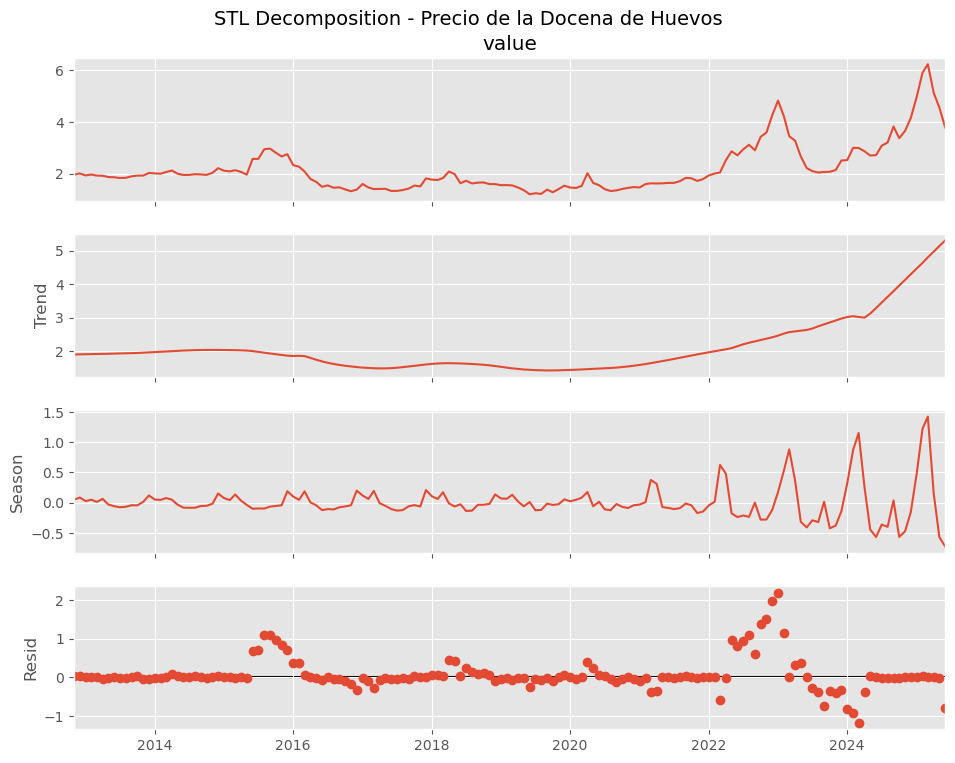

In [26]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# STL con estacionalidad anual (por eso 12)
stl = STL(df['value'],period=12, robust=True) 
result = stl.fit()

fig = result.plot()
fig.set_size_inches(10, 8)
plt.suptitle("STL Decomposition - Precio de la Docena de Huevos", fontsize=14)
plt.show()


Podemos ver como es cierto esto de la tendencia y estacionalidad presentes ya que podemos ver como la **tendencia va hacia la alta** ya a muy finales de la serie y de estacionalidad parece que hay **dos patrones**, casi como si desde 2014 a 2019 se repitiera el mismo ciclo pero algo paso en **2020** [como podría ser la pandemia] lo que hizo que el patrón aumentara su varianza [Picos mas grandes pero en general es un pico corto y le sigue uno más alto].

# <font color= #bbc28d> **Fundamento Matemático: Modelo ARIMA** </font>

Un modelo ARIMA se define por tres parámetros $(p, d, q)$. Matemáticamente, para una serie de tiempo $y_t$, el modelo se expresa utilizando el operador de rezago (Backshift operator) $B$, donde $B y_t = y_{t-1}$.

La forma canónica es:

$$\phi_p(B) (1 - B)^d Y_t = c + \theta_q(B) \epsilon_t$$

Donde:
* $\phi_p(B) = 1 - \phi_1 B - ... - \phi_p B^p$ es la parte Auto Regresiva (AR).
* $(1 - B)^d$ representa las **d** diferencias necesarias para hacer la serie estacionaria (I).
* $\theta_q(B) = 1 + \theta_1 B + ... + \theta_q B^q$ es la parte de Media Móvil (MA).
* $\epsilon_t$ es un proceso de ruido blanco con media 0 y varianza $\sigma^2$.

## <font color= #66b0b0> &ensp; • **Estacionariedad** </font>
Un supuesto que se tiene al trabajar con modelos **ARIMA** es la estacionariedad, la cuál es la propiedad que mantiene media, varianza y autocovarianza constantes a lo largo del tiempo.

Para validar si una serie de tiempo es estacionaria, se realizan las siguientes pruebas:
- Augmented Dickey-Fuller (ADF)
  - Si el **p-value es menor a 0.05** la serie es **ESTACIONARIA.**
  - Si el **critical value es menor al test statistic** la serie es **ESTACIONARIA.**

In [27]:
# @title Prueba de Dickey-Fuller y Diferenciación
def check_stationarity(series, title="Serie Original"):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    is_stationary = result[1] < 0.05
    print(f"¿Es estacionaria? {'SÍ' if is_stationary else 'NO'}\n")
    return is_stationary

# Revisamos la serie original
check_stationarity(df['value'], "Nivel Original")

# Aplicamos Primera Diferencia (d=1)
df['diff_1'] = df['value'].diff()

# Revisamos la serie diferenciada
check_stationarity(df['diff_1'], "Primera Diferencia (d=1)")

# Creamos una figura con 2 columnas (Subplots)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Serie Original (No Estacionaria)", "Serie Diferenciada (Estacionaria d=1)")
)

# Gráfico 1: Serie Original
fig.add_trace(
    go.Scatter(x=df.index, y=df['value'], name='Original'),
    row=1, col=1
)

# Gráfico 2: Serie Diferenciada
fig.add_trace(
    go.Scatter(x=df.index, y=df['diff_1'], name='Diferenciada'),
    row=1, col=2
)

# Ajustes de diseño
fig.update_layout(
    title_text="Comparativa: Efecto de la Diferenciación",
    showlegend=False, # Ocultamos leyenda
    height=500
)

fig.show()

ADF Test: Nivel Original
Estadístico ADF: -2.4093
p-value: 0.1391
¿Es estacionaria? NO

ADF Test: Primera Diferencia (d=1)
Estadístico ADF: -6.3980
p-value: 0.0000
¿Es estacionaria? SÍ



Podemos ver como nuestra serie original no es estacionaria ya que al realizar la prueba de **ADF** el p-value > $\alpha$, por lo tanto la HO **NO SE RECHAZA**, lo que indica que no es estacionaria. Para lidiar con esto hacemos una primera diferenciación (d = 1) y volvemos a realizar la prueba de ADF, y el resultado ya mejora, el p-value <> $\alpha$ por lo que **SE RECHAZA** la H0, por ende ya es estacionaria y podemos seguir con esta "nueva serie".

## <font color= #66b0b0> &ensp; • **Orden del Modelo (p,q)** </font>
- **La función de autocorrelación (ACF)** entrega valores entre 1 y -1. Con la ACF, se puede evaluar la aleatoriedad y la estacionariedad de una serie temporal. También se puede determinar la presencia de tendencias y patrones estacionales.
- **La función de autocorrelación parcial (PACF)** aísla la correlación directa entre una observación y un rezago específico. La PACF es particularmente útil para determinar el orden de un modelo autorregresivo (AR).

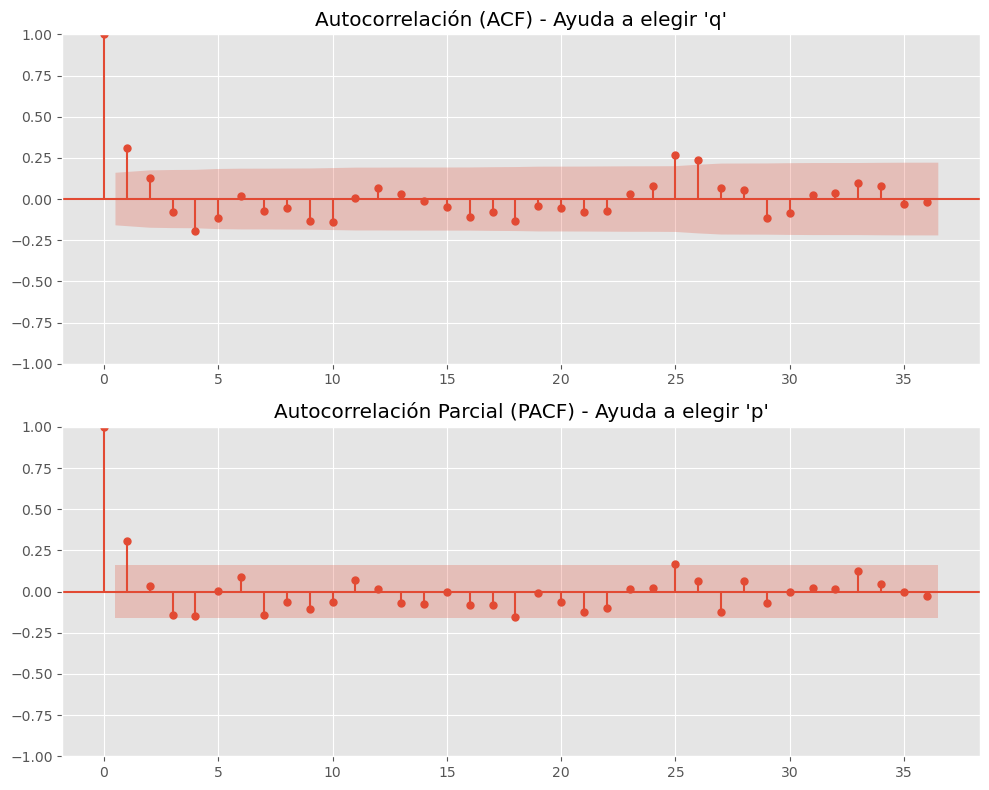

In [28]:
# Gráficas de ACF & PACF
# Usar la serie ya diferenciada ya que establecimos antes que d = 1.
series_analysis = df['diff_1'].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Graficamos ACF (para q)
plot_acf(series_analysis, lags=36, ax=ax1, title="Autocorrelación (ACF) - Ayuda a elegir 'q'")

# Graficamos PACF (para p)
plot_pacf(series_analysis, lags=36, ax=ax2, title="Autocorrelación Parcial (PACF) - Ayuda a elegir 'p'")

plt.tight_layout()
plt.show()

Como podemos ver en las gráficas, parecen haber patrones cada 24 rezagos, esto puede deberse a la estacionalidad que habíamos mencionado previamente, un modelo de ordenes mayor a 5 no se suelen usar ya que significa que hay que usar un modelo más avanzado como **SARIMA** para poder captar estos patrones cada cierta cantidad de rezagos, pero para esta tarea de ARIMA ignoraremos esto y nos quedaremos con los primeros rezagos importantes `p = 1` y `q = 1`.

## <font color= #66b0b0> &ensp; • **MODELO ARIMA (1,1,1)** </font>
Una vez establecido el orden, hay que pasar a modelarlo. Primero que nada dividimos nuestra data en train/test. Para esto definimos un split de 80/20 %.

In [33]:
# Definimos el tamaño del test
test_size = 36

# Train/Test split
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Graficar la serie de entrada
# Graficar serie
fig = px.line(train, x=train.index, y='value', title=f'Serie de Tiempo: Train')
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Índice',

)
fig.show()

In [35]:
# Ajustamos el modelo ARIMA
model = ARIMA(train['value'], order=(1, 1, 1))
results = model.fit()
print(results.summary())

# Realizamos el pronóstico para los pasos del Test set
# start: índice donde empieza el test, end: índice donde termina
forecast_object = results.get_forecast(steps=len(test))
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # 95% confianza

# Convertimos a DataFrame para facilitar el manejo
forecast_df = pd.DataFrame({
    'date': test.index,
    'actual': test['value'],
    'forecast': forecast.values,
    'lower_ci': conf_int.iloc[:, 0].values,
    'upper_ci': conf_int.iloc[:, 1].values
})
forecast_df.set_index('date', inplace=True)

# Cálculo de Métricas de Error
rmse = np.sqrt(mean_squared_error(test['value'], forecast))
mae = mean_absolute_error(test['value'], forecast)
print(f"\n--- Métricas de Evaluación en Test Set ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


fig = go.Figure()
# Datos de Entrenamiento (Histórico)
# Mostramos solo los últimos años para que se vea bien el detalle del final
train_subset = train[train.index > '2018-01-01']

fig.add_trace(go.Scatter(
    x=train_subset.index, y=train_subset['value'],
    mode='lines', name='Train',
    line=dict(color='gray')
))

# Datos Reales (Test)
fig.add_trace(go.Scatter(
    x=test.index, y=test['value'],
    mode='lines+markers', name='Test',
    line=dict(color='green', width=2)
))

# Pronóstico del Modelo
fig.add_trace(go.Scatter(
    x=forecast_df.index, y=forecast_df['forecast'],
    mode='lines+markers', name='ARIMA',
    line=dict(color='red', dash='dash', width=2)
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=forecast_df.index.tolist() + forecast_df.index[::-1].tolist(),
    y=forecast_df['upper_ci'].tolist() + forecast_df['lower_ci'][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Intervalo de Confianza (95%)',
    hoverinfo="skip"
))

fig.update_layout(
    title='Real vs Forecast',
    xaxis_title='Fecha',
    yaxis_title='Indice',
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  121
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  52.809
Date:                Thu, 12 Feb 2026   AIC                            -99.617
Time:                        07:48:01   BIC                            -91.255
Sample:                    11-01-2012   HQIC                           -96.221
                         - 11-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0014     26.299  -5.35e-05      1.000     -51.546      51.543
ma.L1         -0.0014     26.298  -5.17e-05      1.000     -51.544      51.541
sigma2         0.0243      0.002     12.304      0.0

c:\Users\denis\anaconda3\envs\machine\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\denis\anaconda3\envs\machine\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Como podemos ver en el resumen del modelo Statsmodels intentó empezar con parámetros inválidos (no estacionarios / no invertibles), así que decidió empezar en ceros para poder entrenar el ARIMA. Esto puede deberse a que la serie aun no es estacionaria o el orden es muy complejo para esta, así que probemos con otro más sencillo:

## <font color= #66b0b0> &ensp; • **MODELO ARIMA (0,1,0)** </font>

In [36]:
# Ajustamos el modelo ARIMA
model = ARIMA(train['value'], order=(0, 1, 0))
results = model.fit()
print(results.summary())

# Realizamos el pronóstico para los pasos del Test set
# start: índice donde empieza el test, end: índice donde termina
forecast_object = results.get_forecast(steps=len(test))
forecast = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # 95% confianza

# Convertimos a DataFrame para facilitar el manejo
forecast_df = pd.DataFrame({
    'date': test.index,
    'actual': test['value'],
    'forecast': forecast.values,
    'lower_ci': conf_int.iloc[:, 0].values,
    'upper_ci': conf_int.iloc[:, 1].values
})
forecast_df.set_index('date', inplace=True)

# Cálculo de Métricas de Error
rmse = np.sqrt(mean_squared_error(test['value'], forecast))
mae = mean_absolute_error(test['value'], forecast)
print(f"\n--- Métricas de Evaluación en Test Set ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


fig = go.Figure()
# Datos de Entrenamiento (Histórico)
# Mostramos solo los últimos años para que se vea bien el detalle del final
train_subset = train[train.index > '2018-01-01']

fig.add_trace(go.Scatter(
    x=train_subset.index, y=train_subset['value'],
    mode='lines', name='Train',
    line=dict(color='gray')
))

# Datos Reales (Test)
fig.add_trace(go.Scatter(
    x=test.index, y=test['value'],
    mode='lines+markers', name='Test',
    line=dict(color='green', width=2)
))

# Pronóstico del Modelo
fig.add_trace(go.Scatter(
    x=forecast_df.index, y=forecast_df['forecast'],
    mode='lines+markers', name='ARIMA',
    line=dict(color='red', dash='dash', width=2)
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=forecast_df.index.tolist() + forecast_df.index[::-1].tolist(),
    y=forecast_df['upper_ci'].tolist() + forecast_df['lower_ci'][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Intervalo de Confianza (95%)',
    hoverinfo="skip"
))

fig.update_layout(
    title='Real vs Forecast',
    xaxis_title='Fecha',
    yaxis_title='Indice',
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  121
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  52.808
Date:                Thu, 12 Feb 2026   AIC                           -103.616
Time:                        07:51:10   BIC                           -100.829
Sample:                    11-01-2012   HQIC                          -102.484
                         - 11-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0243      0.002     12.857      0.000       0.021       0.028
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                69.40
Prob(Q):                              0.91   Pr

## <font color= #66b0b0> &ensp; • **Conclusiones** </font>

Con este nuevo orden, el modelo de arima si logro encontrar los puntos iniciales que funcionaran, además podemos ver como los criterios de **AIC, BIC & HIQC** disminuyeron [entre más pequeño, mejor ajuste] por lo que podemos decir que este modelo ARIMA(0,1,0) es mejor que ARIMA(1,1,1).

Como se pudo observar en todas las gráficas, no había un orden en específico que pudiera darnos un mejor pornóstico diferente a la media de la serie, por eso la predicción es una línea recta que parece indicar que el modelo no sirve, pero en realidad lo mejor que puede hacer un ARIMA es el promedio mas un error.